In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 14,
    }
)

results = xr.open_dataarray("../plotting_data/0069_results.nc")
lons, lats = results.lon, results.lat
results_rsds = xr.open_dataarray("../plotting_data/0069_results_rsds.nc")

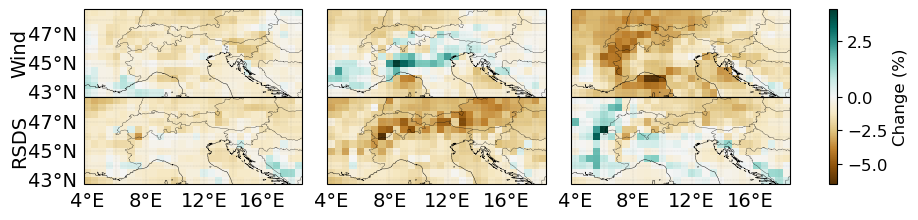

In [ ]:
# Determine min/max
v_min_dmpe = min(ds.min() for ds in results)
v_max_dmpe = max(ds.max() for ds in results)
v_min_rsds = min(ds.min() for ds in results_rsds)
v_max_rsds = max(ds.max() for ds in results_rsds)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(9, 2.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False,
)

plt.subplots_adjust(
    left=0.12, right=0.98, top=0.90, bottom=0.2, wspace=0.05, hspace=0.001
)

norm_dmpe = TwoSlopeNorm(vmin=v_min_dmpe, vcenter=0, vmax=v_max_dmpe)
norm_rsds = TwoSlopeNorm(vmin=v_min_rsds, vcenter=0, vmax=v_max_rsds)
cmap = plt.get_cmap("BrBG")

for i in range(3):
    ax0 = axes[0, i]
    ax0.coastlines(linewidth=0.3)
    ax0.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax0.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    im0 = ax0.pcolormesh(
        lons, lats, results[i], transform=ccrs.PlateCarree(), cmap=cmap, norm=norm_dmpe
    )

    gl0 = ax0.gridlines(
        draw_labels=True, linewidth=0.2, color="gray", alpha=0.5, linestyle="--"
    )
    gl0.top_labels = False
    gl0.right_labels = False
    gl0.bottom_labels = False
    gl0.left_labels = i == 0

    # --- ROW 2: results_rsds (Bottom) ---
    ax1 = axes[1, i]
    ax1.coastlines(linewidth=0.3)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax1.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    im1 = ax1.pcolormesh(
        lons,
        lats,
        results_rsds[i],
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm_rsds,
    )

    gl1 = ax1.gridlines(
        draw_labels=True, linewidth=0.2, color="gray", alpha=0.5, linestyle="--"
    )
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.bottom_labels = True
    gl1.left_labels = i == 0

cbar = fig.colorbar(
    im1, ax=axes, orientation="vertical", fraction=0.02, pad=0.05  # or im0
)
cbar.set_label("Change (%)", size=12)

axes[0, 0].annotate(
    "Wind",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="right",
)
axes[1, 0].annotate(
    "RSDS",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="right",
)
plt.savefig(
    "../plot/0069_internal_var.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()